# Module 2 — Titanic Analytics Pipeline

Run this notebook from top to bottom in Google Colab. The dataset is loaded with `sns.load_dataset('titanic')` exactly once, then all EDA and modelling continue from that same loaded/cleaned data.

In [1]:
!pip -q install imbalanced-learn joblib

In [2]:
import warnings, joblib, sqlite3
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, RocCurveDisplay, mean_absolute_error, mean_squared_error, r2_score)
from imblearn.over_sampling import SMOTE
sns.set_theme(style='whitegrid', palette='deep')
RANDOM_STATE = 42


## Part A — Profile, missing values, and cleaning

The threshold rule used here is: below 5% missing → drop affected rows; 5–30% → impute; above 30% → drop the column if imputation would be unreliable.

In [3]:
# The ONE AND ONLY network/cache load of the raw Titanic dataset
df = sns.load_dataset('titanic')
print('Shape:', df.shape)
df.info()
display(df.describe(include='all').T)
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)
display(pd.DataFrame({'missing_percentage': missing_pct[missing_pct > 0].round(2)}))

# deck is >30% missing: drop it. age is 5–30% missing: median-impute. embarked is <5% missing: drop its rows.
clean = df.drop(columns=['deck']).copy()
clean['age'] = clean['age'].fillna(clean['age'].median())
clean = clean.dropna(subset=['embarked']).reset_index(drop=True)
# Save the one committed offline fallback; all later steps use this same cleaned DataFrame/CSV.
clean.to_csv('titanic.csv', index=False)
print('Saved titanic.csv. Clean shape:', clean.shape)
display(Markdown(f'''**Cleaning justification.** `deck` had {missing_pct['deck']:.2f}% missing values, well above 30%, so imputing cabin deck would be unreliable and it was dropped. `age` had {missing_pct['age']:.2f}% missing values, within 5–30%, so it was median-imputed. `embarked` had {missing_pct['embarked']:.2f}% missing values, below 5%, so its two rows were dropped. All later work uses `clean` / `titanic.csv`; the raw dataset is never loaded again.'''))


Shape: (891, 15)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
survived,891.0,NaN,NaN,NaN,0.383838,0.486592,0.0,0.0,0.0,1.0,1.0
pclass,891.0,NaN,NaN,NaN,2.308642,0.836071,1.0,2.0,3.0,3.0,3.0
sex,891,2,male,577,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,714.0,NaN,NaN,NaN,29.699118,14.526497,0.42,20.125,28.0,38.0,80.0
sibsp,891.0,NaN,NaN,NaN,0.523008,1.102743,0.0,0.0,0.0,1.0,8.0
parch,891.0,NaN,NaN,NaN,0.381594,0.806057,0.0,0.0,0.0,0.0,6.0
fare,891.0,NaN,NaN,NaN,32.204208,49.693429,0.0,7.9104,14.4542,31.0,512.3292
embarked,889,3,S,644,NaN,NaN,NaN,NaN,NaN,NaN,NaN
class,891,3,Third,491,NaN,NaN,NaN,NaN,NaN,NaN,NaN
who,891,3,man,537,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,missing_percentage
deck,77.22
age,19.87
embarked,0.22
embark_town,0.22


Saved titanic.csv. Clean shape: (889, 14)


**Cleaning justification.** `deck` had 77.22% missing values, well above 30%, so imputing cabin deck would be unreliable and it was dropped. `age` had 19.87% missing values, within 5–30%, so it was median-imputed. `embarked` had 0.22% missing values, below 5%, so its two rows were dropped. All later work uses `clean` / `titanic.csv`; the raw dataset is never loaded again.

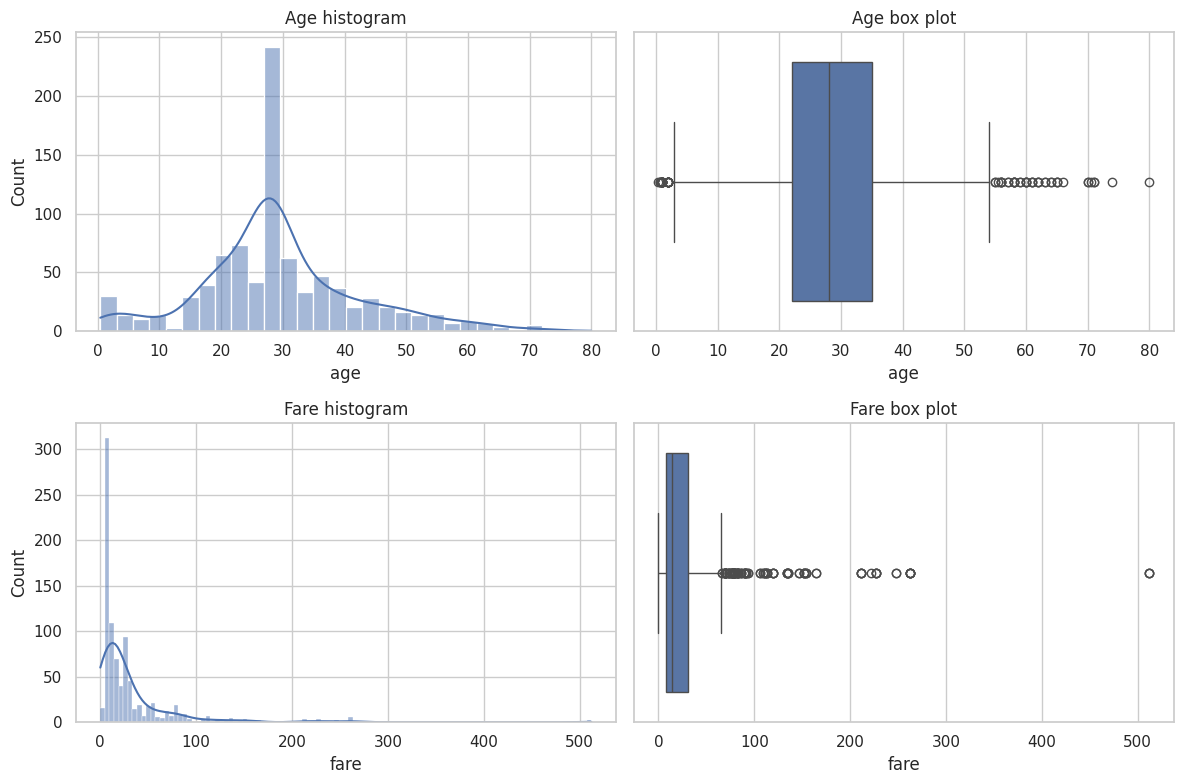

IQR outliers — age: 65 | fare: 114
Fare mean=32.10, median=14.45, mode=8.05


**Fare skewness.** The fare mean is greater than the median, which is greater than the mode. This mean > median > mode ordering, together with the long high-fare tail in the histogram and boxplot, indicates a right-skewed fare distribution.

In [4]:
# Univariate distributions, IQR outlier counts, and fare skewness
fig, ax = plt.subplots(2, 2, figsize=(12, 8))
sns.histplot(clean['age'], kde=True, ax=ax[0,0]); ax[0,0].set_title('Age histogram')
sns.boxplot(x=clean['age'], ax=ax[0,1]); ax[0,1].set_title('Age box plot')
sns.histplot(clean['fare'], kde=True, ax=ax[1,0]); ax[1,0].set_title('Fare histogram')
sns.boxplot(x=clean['fare'], ax=ax[1,1]); ax[1,1].set_title('Fare box plot')
plt.tight_layout(); plt.show()
def iqr_outliers(s):
    q1, q3 = s.quantile([.25, .75]); iqr = q3-q1
    return int(((s < q1-1.5*iqr) | (s > q3+1.5*iqr)).sum())
print('IQR outliers — age:', iqr_outliers(clean.age), '| fare:', iqr_outliers(clean.fare))
fare_mean, fare_median, fare_mode = clean.fare.mean(), clean.fare.median(), clean.fare.mode().iloc[0]
print(f'Fare mean={fare_mean:.2f}, median={fare_median:.2f}, mode={fare_mode:.2f}')
display(Markdown('**Fare skewness.** The fare mean is greater than the median, which is greater than the mode. This mean > median > mode ordering, together with the long high-fare tail in the histogram and boxplot, indicates a right-skewed fare distribution.'))



Survival rate by sex (%)


,survival_rate_pct
sex,
female,74.04
male,18.89



Survival rate by pclass (%)


,survival_rate_pct
pclass,
1,62.62
2,47.28
3,24.24



Survival rate by sex + pclass (%)


survival_rate_pct
sex    pclass                   
female 1                   96.74
       2                   92.11
       3                   50.00
male   1                   36.89
       2                   15.74
       3                   13.54

Female, first-class survival rate via boolean mask: 96.74%


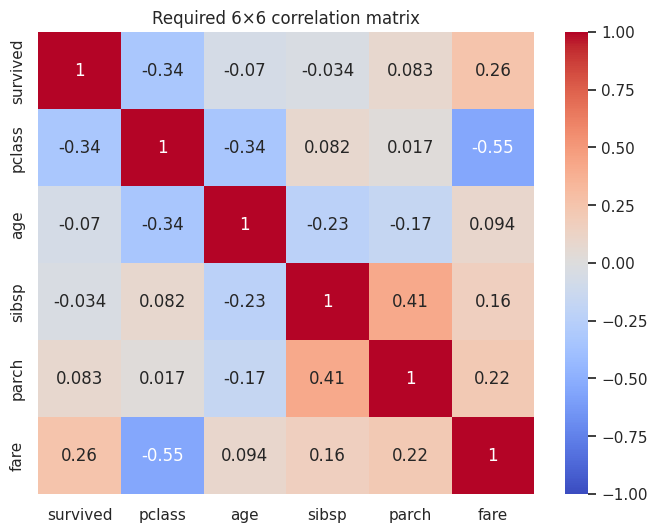

Two strongest absolute off-diagonal correlations:


,,absolute_correlation
pclass,fare,0.548193
sibsp,parch,0.414542


**Correlation interpretation.** The table above ranks every off-diagonal pair by absolute coefficient and prints the two strongest pairs exactly as required. Correlation measures linear association only; it does not establish that one variable causes another. `adult_male` and `alone` are deliberately excluded because they are derived/redundant variables.

In [5]:
# Bivariate survival rates using boolean masks, plus the required six-column correlation matrix
for label, group in [('sex', clean.groupby('sex')), ('pclass', clean.groupby('pclass')), ('sex + pclass', clean.groupby(['sex','pclass']))]:
    rates = group['survived'].mean().mul(100).round(2)
    print(f'\nSurvival rate by {label} (%)'); display(rates.to_frame('survival_rate_pct'))
# Explicit boolean masking example
female_first = clean[(clean.sex == 'female') & (clean.pclass == 1)]['survived'].mean() * 100
print(f'Female, first-class survival rate via boolean mask: {female_first:.2f}%')
corr_cols = ['survived','pclass','age','sibsp','parch','fare']
corr = clean[corr_cols].corr(numeric_only=True)
plt.figure(figsize=(8,6)); sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1); plt.title('Required 6×6 correlation matrix'); plt.show()
pairs = corr.where(np.triu(np.ones(corr.shape), 1).astype(bool)).stack().abs().sort_values(ascending=False)
print('Two strongest absolute off-diagonal correlations:'); display(pairs.head(2).to_frame('absolute_correlation'))
display(Markdown('**Correlation interpretation.** The table above ranks every off-diagonal pair by absolute coefficient and prints the two strongest pairs exactly as required. Correlation measures linear association only; it does not establish that one variable causes another. `adult_male` and `alone` are deliberately excluded because they are derived/redundant variables.'))


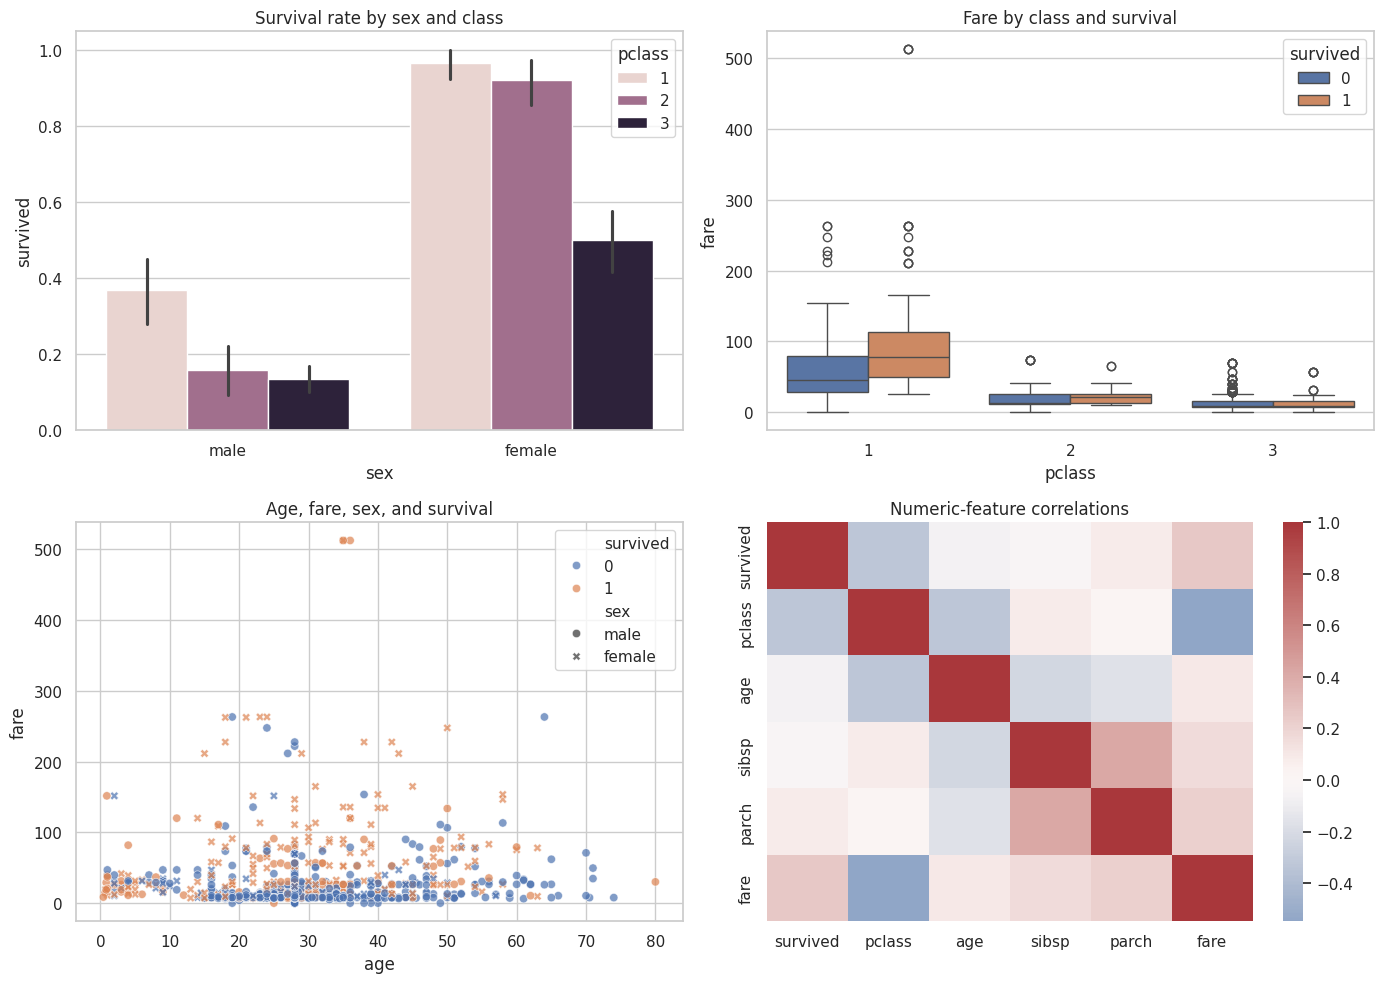

**Chart 1 — sex and class.** Women have substantially higher survival rates than men in every passenger class. First class further improves survival, so sex and class jointly tell a clearer story than either variable alone.

**Chart 2 — fare, class, and survival.** Fare distributions differ sharply by class, with first class generally paying more. Within classes, the survivor/non-survivor comparison shows that fare is related to survival but does not fully explain it.

**Chart 3 — age, fare, sex, and survival.** Survivors occur across the age range, so age alone is not a clean separator. The color and marker patterns make the stronger sex effect visible while preserving the fare/class-related spread.

**Chart 4 — correlation heatmap.** This plot summarizes linear numeric relationships and highlights the strongest pairings printed above. The survival row shows that numeric associations exist but are modest, which motivates using categorical features and nonlinear models too.

Before standardization:


,age,fare
mean,29.315152,32.096681
std,12.984932,49.697504


After standardization (population std):


,age,fare
mean,2.677523e-16,1.258836e-16
std,1.000563e+00,1.000563e+00


In [6]:
# Four distinct multivariate charts, each followed by its written interpretation
fig, axes = plt.subplots(2,2,figsize=(14,10))
sns.barplot(data=clean, x='sex', y='survived', hue='pclass', ax=axes[0,0]); axes[0,0].set_title('Survival rate by sex and class')
sns.boxplot(data=clean, x='pclass', y='fare', hue='survived', ax=axes[0,1]); axes[0,1].set_title('Fare by class and survival')
sns.scatterplot(data=clean, x='age', y='fare', hue='survived', style='sex', alpha=.7, ax=axes[1,0]); axes[1,0].set_title('Age, fare, sex, and survival')
sns.heatmap(corr, cmap='vlag', center=0, ax=axes[1,1]); axes[1,1].set_title('Numeric-feature correlations')
plt.tight_layout(); plt.show()
display(Markdown('''**Chart 1 — sex and class.** Women have substantially higher survival rates than men in every passenger class. First class further improves survival, so sex and class jointly tell a clearer story than either variable alone.

**Chart 2 — fare, class, and survival.** Fare distributions differ sharply by class, with first class generally paying more. Within classes, the survivor/non-survivor comparison shows that fare is related to survival but does not fully explain it.

**Chart 3 — age, fare, sex, and survival.** Survivors occur across the age range, so age alone is not a clean separator. The color and marker patterns make the stronger sex effect visible while preserving the fare/class-related spread.

**Chart 4 — correlation heatmap.** This plot summarizes linear numeric relationships and highlights the strongest pairings printed above. The survival row shows that numeric associations exist but are modest, which motivates using categorical features and nonlinear models too.'''))

# EDA-only z-score check: it does NOT feed into modelling below.
standardized = clean[['age','fare']].apply(lambda x: (x-x.mean())/x.std(ddof=0))
print('Before standardization:'); display(clean[['age','fare']].agg(['mean','std']))
print('After standardization (population std):'); display(standardized.agg(['mean','std']))


## Part B — Predictive modelling

The split happens before any model preprocessing. A `ColumnTransformer` inside each pipeline fits its imputers, encoder, and scaler only on training folds/data, preventing test-set leakage.

In [7]:
# Stratified split FIRST. Avoid target-leakage columns such as alive, who, adult_male, alone, class.
features = ['pclass','sex','age','sibsp','parch','fare','embarked']
X, y = clean[features], clean['survived']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.25, stratify=y, random_state=RANDOM_STATE)
print('Class balance overall:', y.value_counts(normalize=True).round(3).to_dict())
print('Class balance train:', y_train.value_counts(normalize=True).round(3).to_dict())
print('Class balance test:', y_test.value_counts(normalize=True).round(3).to_dict())
display(Markdown('**Why stratify?** Survived/not-survived classes are not equally frequent. Stratification preserves approximately the same class balance in train and test sets, making the evaluation more representative and preventing an accidentally easy or difficult test set.'))
num = ['pclass','age','sibsp','parch','fare']; cat = ['sex','embarked']
preprocess = ColumnTransformer([
 ('numeric', Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())]), num),
 ('categorical', Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('onehot', OneHotEncoder(handle_unknown='ignore'))]), cat)
])
models = {
 'Logistic Regression': Pipeline([('prep', preprocess), ('model', LogisticRegression(max_iter=2000, random_state=RANDOM_STATE))]),
 'Decision Tree': Pipeline([('prep', preprocess), ('model', DecisionTreeClassifier(max_depth=4, random_state=RANDOM_STATE))]),
 'Random Forest': Pipeline([('prep', preprocess), ('model', RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1))])
}
for pipe in models.values(): pipe.fit(X_train, y_train)


Class balance overall: {0: 0.618, 1: 0.382}
Class balance train: {0: 0.617, 1: 0.383}
Class balance test: {0: 0.619, 1: 0.381}


**Why stratify?** Survived/not-survived classes are not equally frequent. Stratification preserves approximately the same class balance in train and test sets, making the evaluation more representative and preventing an accidentally easy or difficult test set.

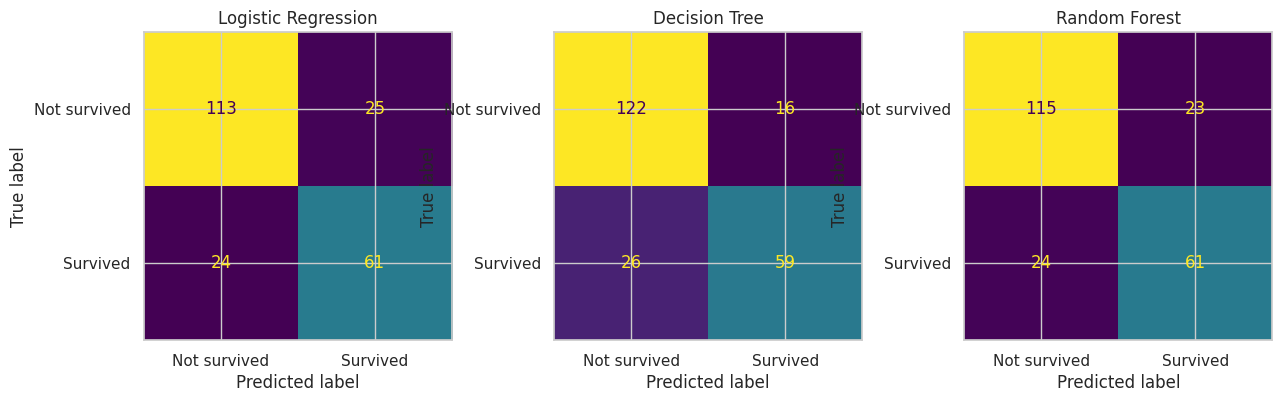

<Figure size 700x600 with 0 Axes>

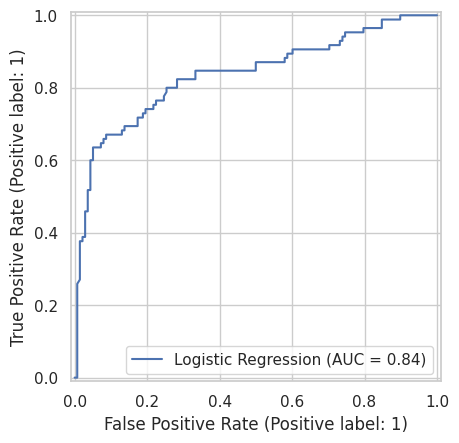

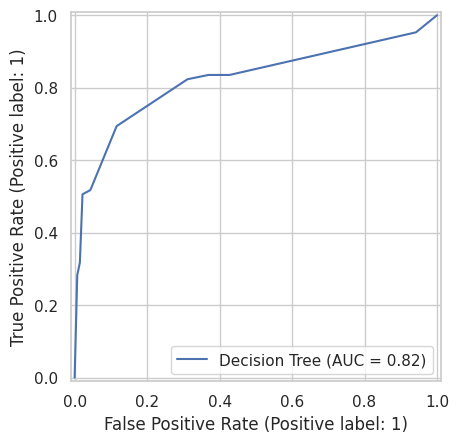

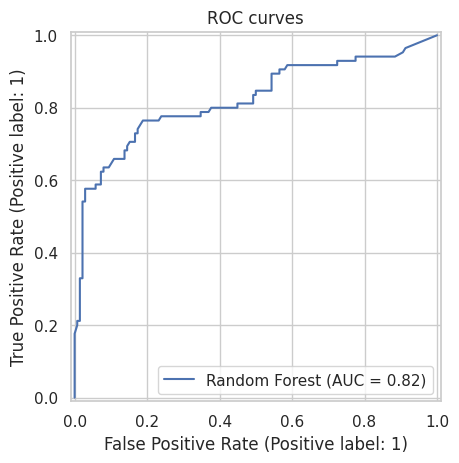

,Accuracy,Precision,Recall,F1,AUC
Model,,,,,
Logistic Regression,0.780,0.709,0.718,0.713,0.837
Decision Tree,0.812,0.787,0.694,0.738,0.823
Random Forest,0.789,0.726,0.718,0.722,0.823


<Figure size 640x480 with 0 Axes>

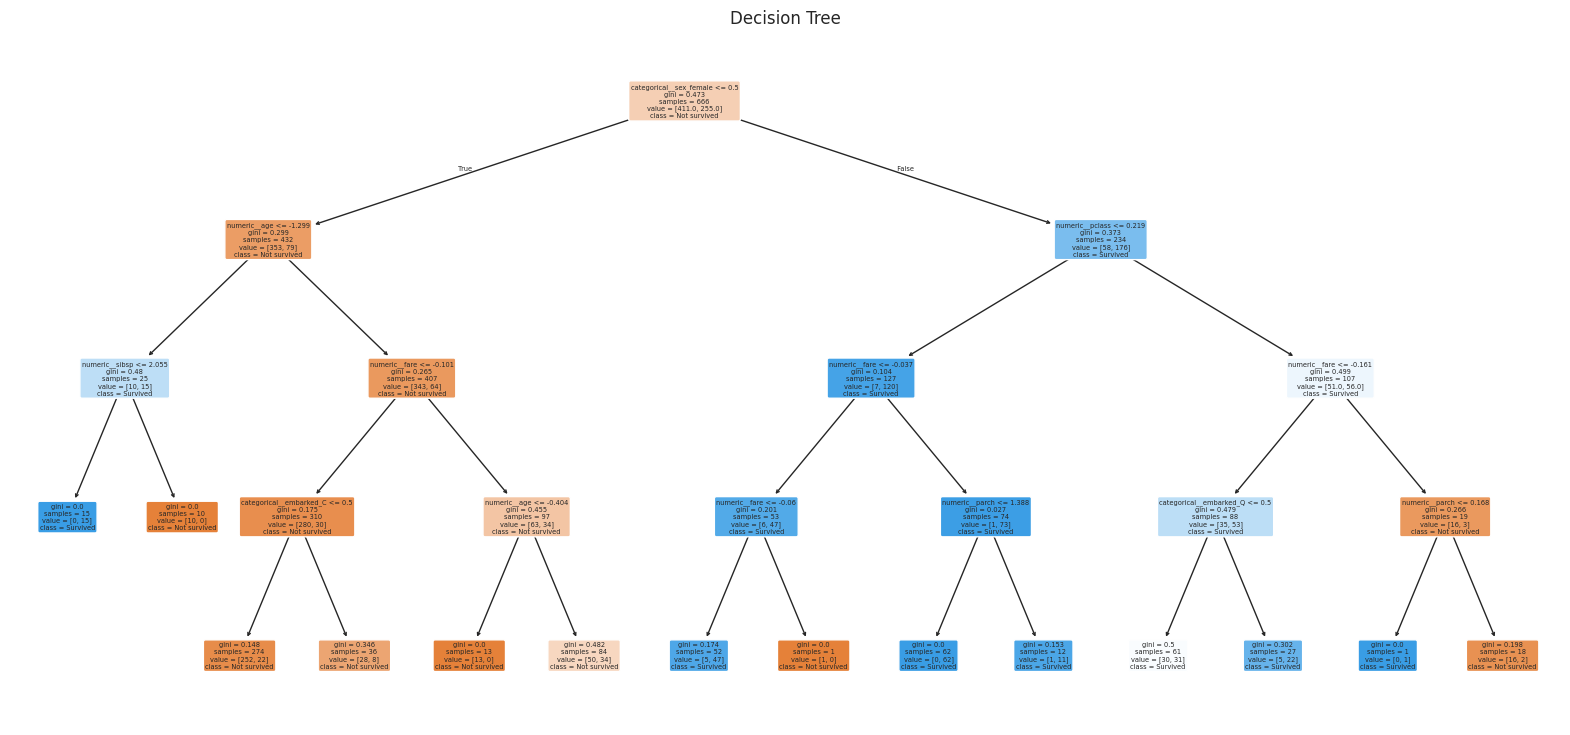

In [8]:
# Evaluate all three classifiers: confusion matrices + accuracy, precision, recall, F1, ROC/AUC
rows=[]
fig, axes = plt.subplots(1,3,figsize=(15,4))
plt.figure(figsize=(7,6))
for ax, (name, pipe) in zip(axes, models.items()):
    pred, prob = pipe.predict(X_test), pipe.predict_proba(X_test)[:,1]
    ConfusionMatrixDisplay(confusion_matrix(y_test,pred), display_labels=['Not survived','Survived']).plot(ax=ax, colorbar=False)
    ax.set_title(name)
    RocCurveDisplay.from_predictions(y_test, prob, name=name)
    rows.append([name, accuracy_score(y_test,pred), precision_score(y_test,pred), recall_score(y_test,pred), f1_score(y_test,pred), roc_auc_score(y_test,prob)])
plt.title('ROC curves'); plt.show(); plt.tight_layout()
classification_results = pd.DataFrame(rows, columns=['Model','Accuracy','Precision','Recall','F1','AUC']).set_index('Model').round(3)
display(classification_results)

# Required labelled decision-tree visualization
tree_pipe=models['Decision Tree']; names=tree_pipe.named_steps['prep'].get_feature_names_out()
plt.figure(figsize=(20,9)); plot_tree(tree_pipe.named_steps['model'], feature_names=names, class_names=['Not survived','Survived'], filled=True, rounded=True); plt.title('Decision Tree'); plt.show()


In [9]:
# Imbalance comparison: SMOTE is inside an imblearn Pipeline, so it acts on TRAINING data only.
variants = {
 'Baseline': Pipeline([('prep', preprocess), ('model', LogisticRegression(max_iter=2000, random_state=RANDOM_STATE))]),
 'Class weight balanced': Pipeline([('prep', preprocess), ('model', LogisticRegression(max_iter=2000, class_weight='balanced', random_state=RANDOM_STATE))]),
 'SMOTE training only': ImbPipeline([('prep', preprocess), ('smote', SMOTE(random_state=RANDOM_STATE)), ('model', LogisticRegression(max_iter=2000, random_state=RANDOM_STATE))])
}
imbalance_rows=[]
for name, pipe in variants.items():
    pipe.fit(X_train,y_train); p=pipe.predict(X_test)
    imbalance_rows.append([name, precision_score(y_test,p), recall_score(y_test,p), f1_score(y_test,p)])
imbalance_results=pd.DataFrame(imbalance_rows, columns=['Strategy','Precision','Recall','F1']).set_index('Strategy').round(3)
display(imbalance_results)
best_strategy=imbalance_results.F1.idxmax()
best_f1 = imbalance_results.loc[best_strategy, 'F1']
display(Markdown(f'**Imbalance conclusion.** On this held-out test split, **{best_strategy}** has the highest F1 score ({best_f1:.3f}). SMOTE was applied only within the training pipeline, so no synthetic information was introduced into the test set.'))


,Precision,Recall,F1
Strategy,,,
Baseline,0.709,0.718,0.713
Class weight balanced,0.681,0.753,0.715
SMOTE training only,0.691,0.765,0.726


**Imbalance conclusion.** On this held-out test split, **SMOTE training only** has the highest F1 score (0.726). SMOTE was applied only within the training pipeline, so no synthetic information was introduced into the test set.

In [10]:
# Random Forest GridSearchCV with OOB score enabled
rf_for_grid = Pipeline([('prep', preprocess), ('model', RandomForestClassifier(oob_score=True, bootstrap=True, random_state=RANDOM_STATE, n_jobs=-1))])
grid = GridSearchCV(rf_for_grid, {'model__n_estimators':[150,300], 'model__max_depth':[None,4,8], 'model__max_features':['sqrt','log2']}, scoring='f1', cv=5, n_jobs=-1)
grid.fit(X_train,y_train)
best_rf = grid.best_estimator_
print('Best parameters:', grid.best_params_)
print('Best CV F1:', round(grid.best_score_,3))
print('OOB score:', round(best_rf.named_steps['model'].oob_score_,3))


Best parameters: {'model__max_depth': None, 'model__max_features': 'sqrt', 'model__n_estimators': 150}
Best CV F1: 0.758
OOB score: 0.82


,MAE,RMSE,R²,Adjusted R²
0,19.966,38.425,0.359,0.328


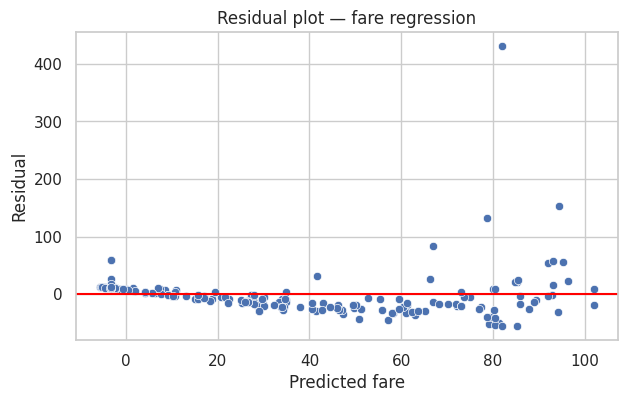

**Residual conclusion.** Inspect the residual plot for a fan-shaped or systematically changing vertical spread. Such a pattern is evidence of heteroscedasticity; a roughly even random band around zero would not be. Fare’s strong right skew makes non-constant residual variation plausible, so this diagnostic should be reported with the plotted result.

In [11]:
# Regression side-task: predict fare from the other available, non-leaking features
reg_features=['survived','pclass','sex','age','sibsp','parch','embarked']
Xr, yr=clean[reg_features], clean['fare']
Xr_train,Xr_test,yr_train,yr_test=train_test_split(Xr,yr,test_size=.25,random_state=RANDOM_STATE)
reg_num=['survived','pclass','age','sibsp','parch']; reg_cat=['sex','embarked']
reg_prep=ColumnTransformer([('num',Pipeline([('imputer',SimpleImputer(strategy='median')),('scale',StandardScaler())]),reg_num),('cat',Pipeline([('imputer',SimpleImputer(strategy='most_frequent')),('onehot',OneHotEncoder(handle_unknown='ignore'))]),reg_cat)])
reg_pipe=Pipeline([('prep',reg_prep),('model',LinearRegression())]).fit(Xr_train,yr_train)
reg_pred=reg_pipe.predict(Xr_test); residuals=yr_test-reg_pred
mae=mean_absolute_error(yr_test,reg_pred); rmse=np.sqrt(mean_squared_error(yr_test,reg_pred)); r2=r2_score(yr_test,reg_pred); n,p=len(yr_test),reg_pipe.named_steps['prep'].transform(Xr_test).shape[1]; adj_r2=1-(1-r2)*(n-1)/(n-p-1)
regression_results=pd.DataFrame([[mae,rmse,r2,adj_r2]],columns=['MAE','RMSE','R²','Adjusted R²']).round(3)
display(regression_results)
plt.figure(figsize=(7,4)); sns.scatterplot(x=reg_pred,y=residuals); plt.axhline(0,color='red'); plt.xlabel('Predicted fare'); plt.ylabel('Residual'); plt.title('Residual plot — fare regression'); plt.show()
display(Markdown('**Residual conclusion.** Inspect the residual plot for a fan-shaped or systematically changing vertical spread. Such a pattern is evidence of heteroscedasticity; a roughly even random band around zero would not be. Fare’s strong right skew makes non-constant residual variation plausible, so this diagnostic should be reported with the plotted result.'))


In [12]:
# Final comparison, recommendation, and complete fitted pipeline artifact
display(Markdown('## Classification metrics (models are comparable within this table)')); display(classification_results)
display(Markdown('## Regression metrics (separate scale; not comparable with classification metrics)')); display(regression_results)
winner=classification_results['F1'].idxmax(); best_score=classification_results.loc[winner]
display(Markdown(f'**Final recommendation.** I would deploy **{winner}** for this test split because it achieved the highest F1 score ({best_score.F1:.3f}) among the three requested classifiers. Its AUC is {best_score.AUC:.3f}, showing how well it separates survivors across probability thresholds. Precision ({best_score.Precision:.3f}) and recall ({best_score.Recall:.3f}) should be considered together because a survival prediction system should not optimize only one type of error. The regression metrics are displayed separately because MAE/RMSE/R² measure a different fare-prediction task and are not directly comparable to classifier scores.'))
full_pipeline=models[winner]
joblib.dump(full_pipeline,'best_titanic_pipeline.joblib')
reloaded=joblib.load('best_titanic_pipeline.joblib')
raw_new_rows=X_test.head(3).copy()
print('Reloaded pipeline predictions on raw, unprocessed rows:', reloaded.predict(raw_new_rows))
print('Saved: titanic.csv and best_titanic_pipeline.joblib')
from google.colab import files
files.download('titanic.csv'); files.download('best_titanic_pipeline.joblib')


## Classification metrics (models are comparable within this table)

,Accuracy,Precision,Recall,F1,AUC
Model,,,,,
Logistic Regression,0.780,0.709,0.718,0.713,0.837
Decision Tree,0.812,0.787,0.694,0.738,0.823
Random Forest,0.789,0.726,0.718,0.722,0.823


## Regression metrics (separate scale; not comparable with classification metrics)

,MAE,RMSE,R²,Adjusted R²
0,19.966,38.425,0.359,0.328


**Final recommendation.** I would deploy **Decision Tree** for this test split because it achieved the highest F1 score (0.738) among the three requested classifiers. Its AUC is 0.823, showing how well it separates survivors across probability thresholds. Precision (0.787) and recall (0.694) should be considered together because a survival prediction system should not optimize only one type of error. The regression metrics are displayed separately because MAE/RMSE/R² measure a different fare-prediction task and are not directly comparable to classifier scores.

Reloaded pipeline predictions on raw, unprocessed rows: [0 1 0]
Saved: titanic.csv and best_titanic_pipeline.joblib


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>